# Greek Equity Portfolio Optimization & Risk Analytics

A Financial Mathematics + Python case study built around five large Greek-listed equities:

- **PPC / ΔΕΗ** — `PPC.AT`
- **OTE / Hellenic Telecommunications Organization** — `HTO.AT`
- **GEK TERNA** — `GEKTERNA.AT`
- **Motor Oil Hellas** — `MOH.AT`
- **National Bank of Greece** — `ETE.AT`

Market proxy:

- **ATHEX Composite Index** — `GD.AT`

The project develops the course logic from portfolio returns and covariance to Markowitz optimization, the Capital Market Line, CAPM, and portfolio risk metrics.

$$
\text{Returns}
\rightarrow
\text{Covariance}
\rightarrow
\text{Diversification}
\rightarrow
\text{Markowitz}
\rightarrow
\text{Efficient Frontier}
\rightarrow
\text{Tangency Portfolio}
\rightarrow
\text{CAPM}
\rightarrow
\text{VaR / CVaR}
$$

The implementation is rebuilt for current Greek-market data rather than reproducing the old classroom dataset.

In [14]:
import warnings
warnings.filterwarnings("ignore")

from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.optimize import minimize
from scipy.stats import norm

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

TRADING_DAYS = 252
START_DATE = "2018-01-01"
END_DATE = "2026-09-13"

ASSETS = {
    "PPC": "PPC.AT",
    "OTE": "HTO.AT",
    "GEK TERNA": "GEKTERNA.AT",
    "Motor Oil": "MOH.AT",
    "National Bank": "ETE.AT",
}

MARKET_TICKER = "GD.AT"

## 1. Portfolio returns

For asset $i$,

$$
R_i(t)
=
\frac{P_i(t+1)-P_i(t)}{P_i(t)}.
$$

For small movements,

$$
R_i(t)
\approx
\ln\left(\frac{P_i(t+1)}{P_i(t)}\right).
$$

If $w_i$ is the fraction of wealth invested in asset $i$, then

$$
\boxed{
R_P(t)=\sum_{i=1}^{N} w_i R_i(t)
}
$$

with

$$
\sum_{i=1}^{N}w_i=1.
$$

We use **simple daily returns** for optimization because the weighted-average portfolio identity is exact for simple returns.

## 2. Download and align Greek-market data

All portfolio assets and the benchmark are listed in Athens, so the experiment avoids mixing exchange calendars.

Prices are downloaded with `auto_adjust=True` and then aligned on common observations.

In [15]:
all_tickers = list(ASSETS.values()) + [MARKET_TICKER]

raw = yf.download(
    all_tickers,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)

if raw.empty:
    raise RuntimeError("No market data were downloaded.")

if isinstance(raw.columns, pd.MultiIndex):
    prices_all = raw["Close"].copy()
else:
    prices_all = raw.copy()

prices_all = prices_all[all_tickers].dropna(how="any")

rename_map = {ticker: name for name, ticker in ASSETS.items()}
rename_map[MARKET_TICKER] = "ATHEX Composite"

prices_all = prices_all.rename(columns=rename_map)

asset_names = list(ASSETS.keys())
prices = prices_all[asset_names]
market_price = prices_all["ATHEX Composite"]

print("Common observations:", len(prices_all))
print("Date range:", prices_all.index.min().date(), "to", prices_all.index.max().date())
prices_all.tail()

Common observations: 2157
Date range: 2018-01-02 to 2026-09-11


Ticker,PPC,OTE,GEK TERNA,Motor Oil,National Bank,ATHEX Composite
Date,,,,,,
2026-09-07,24.260000,19.799999,43.799999,63.150002,17.525000,"2,702.540039"
2026-09-08,24.000000,19.700001,44.200001,65.000000,17.600000,"2,706.649902"
2026-09-09,24.660000,20.120001,44.320000,67.199997,17.285000,"2,701.689941"
2026-09-10,24.860001,19.740000,45.560001,64.800003,17.340000,"2,697.580078"
2026-09-11,24.660000,19.650000,45.299999,66.699997,17.680000,"2,726.489990"


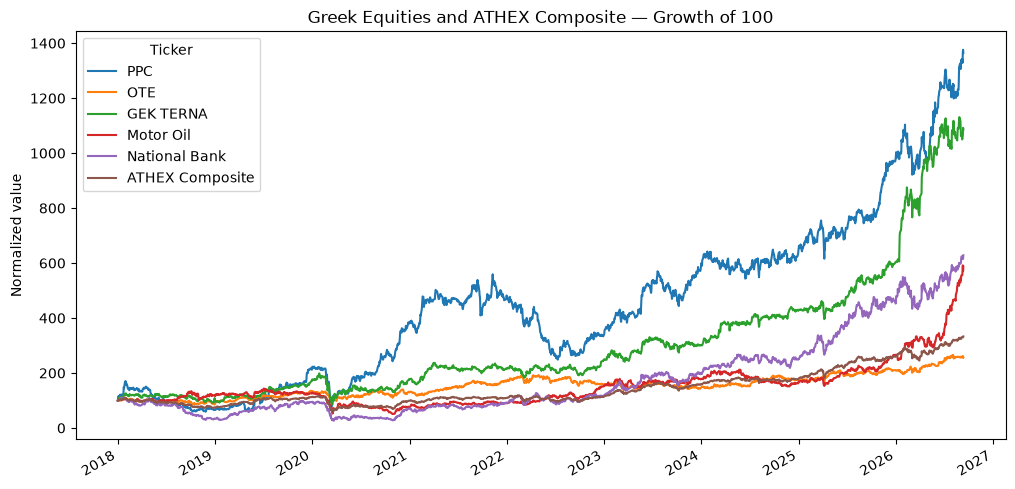

In [16]:
normalized = 100 * prices_all / prices_all.iloc[0]

ax = normalized.plot(
    figsize=(12, 6),
    title="Greek Equities and ATHEX Composite — Growth of 100",
)
ax.set_ylabel("Normalized value")
ax.set_xlabel("")
plt.show()

## 3. Expected return and portfolio risk

Let

$$
\mu
=
E[R]
$$

be the vector of expected asset returns and

$$
\Sigma
=
Cov(R)
$$

the covariance matrix.

For portfolio weights $w$,

$$
\boxed{
E[R_P]=w^\top\mu
}
$$

and

$$
\boxed{
\sigma_P^2=w^\top\Sigma w.
}
$$

The covariance terms are the mathematical source of diversification.

In [17]:
returns_all = prices_all.pct_change().dropna()
returns = returns_all[asset_names]
market_returns = returns_all["ATHEX Composite"]

mu_daily = returns.mean()
cov_daily = returns.cov()

mu_annual = TRADING_DAYS * mu_daily
cov_annual = TRADING_DAYS * cov_daily
vol_annual = np.sqrt(np.diag(cov_annual))

summary = pd.DataFrame({
    "annualized_return": mu_annual,
    "annualized_volatility": vol_annual,
})

summary

,annualized_return,annualized_volatility
Ticker,,
PPC,0.403453,0.442500
OTE,0.142568,0.255714
GEK TERNA,0.338395,0.343768
Motor Oil,0.265781,0.343630
National Bank,0.334264,0.489088


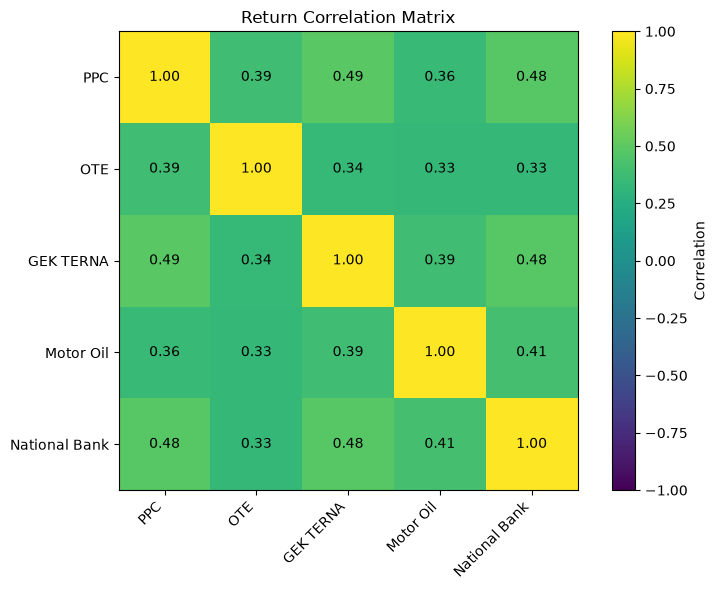

In [18]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Return Correlation Matrix")
plt.tight_layout()
plt.show()

## 4. Diversification experiment

Portfolio variance can be decomposed as

$$
Var(R_P)
=
\sum_i w_i^2 Var(R_i)
+
\sum_{i\ne j}w_iw_jCov(R_i,R_j).
$$

The first term is always non-negative.

The second term depends on the covariance structure. This is why combining imperfectly correlated assets can reduce portfolio risk.

For an equal-weight portfolio,

$$
w_i=\frac{1}{N}.
$$

We evaluate every possible subset of the five Greek equities and calculate the average equal-weight volatility for each portfolio size $N$.

In [19]:
diversification_rows = []

for n_assets in range(1, len(asset_names) + 1):
    for subset in combinations(asset_names, n_assets):
        subset = list(subset)
        w = np.repeat(1 / n_assets, n_assets)
        sub_cov = cov_annual.loc[subset, subset].values

        vol = np.sqrt(w @ sub_cov @ w)

        diversification_rows.append({
            "N": n_assets,
            "assets": ", ".join(subset),
            "annualized_volatility": vol,
        })

diversification = pd.DataFrame(diversification_rows)

diversification_summary = (
    diversification
    .groupby("N")["annualized_volatility"]
    .agg(["mean", "min", "max"])
)

diversification_summary

,mean,min,max
N,,,
1,0.374940,0.255714,0.489088
2,0.316319,0.246107,0.400713
3,0.293764,0.238678,0.344994
4,0.281743,0.256565,0.308840
5,0.274261,0.274261,0.274261


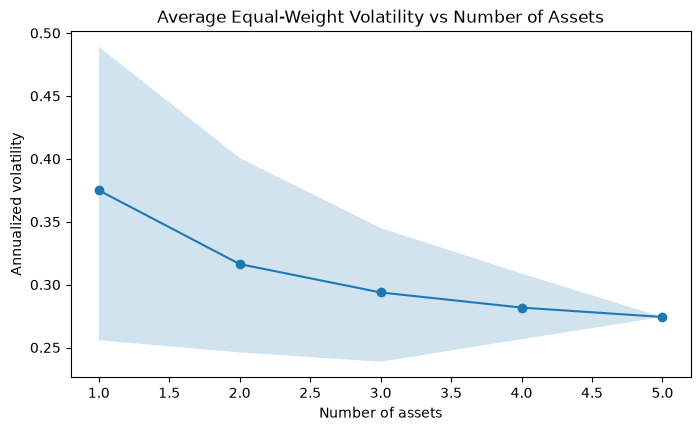

In [20]:
ax = diversification_summary["mean"].plot(
    marker="o",
    figsize=(8, 4.5),
    title="Average Equal-Weight Volatility vs Number of Assets",
)
ax.fill_between(
    diversification_summary.index,
    diversification_summary["min"],
    diversification_summary["max"],
    alpha=0.2,
)
ax.set_xlabel("Number of assets")
ax.set_ylabel("Annualized volatility")
plt.show()

## 5. Monte Carlo portfolio opportunity set

For random long-only weights satisfying

$$
w_i\ge0,
\qquad
\sum_iw_i=1,
$$

each portfolio maps to a point

$$
(\sigma_P,E[R_P]).
$$

The cloud of feasible portfolios provides an intuitive picture of the risk-return opportunity set before formal optimization.

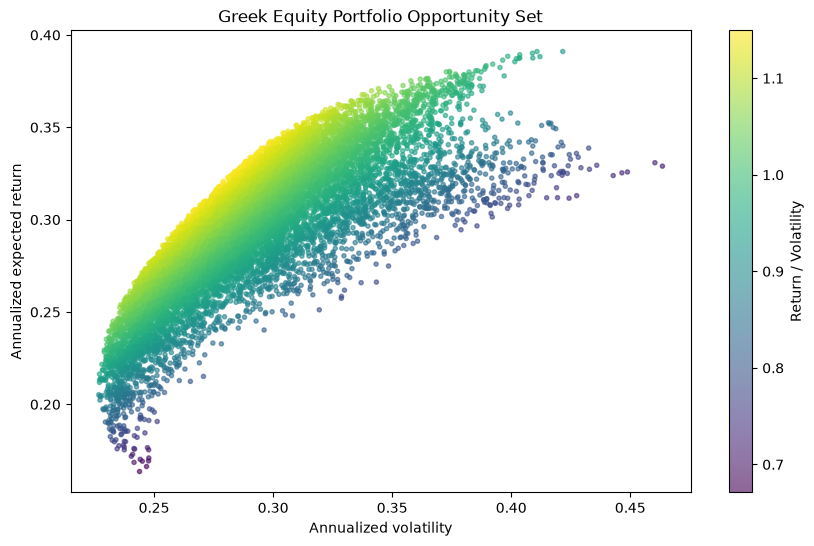

In [21]:
rng = np.random.default_rng(42)

N_SIM = 12000
random_weights = rng.dirichlet(
    alpha=np.ones(len(asset_names)),
    size=N_SIM,
)

sim_returns = random_weights @ mu_annual.values
sim_variances = np.einsum(
    "ij,jk,ik->i",
    random_weights,
    cov_annual.values,
    random_weights,
)
sim_vols = np.sqrt(sim_variances)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    sim_vols,
    sim_returns,
    c=sim_returns / sim_vols,
    s=9,
    alpha=0.6,
)
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized expected return")
plt.title("Greek Equity Portfolio Opportunity Set")
plt.colorbar(scatter, label="Return / Volatility")
plt.show()

## 6. The Markowitz problem

The minimum-variance portfolio for a required return $m$ solves

$$
\boxed{
\min_w
w^\top\Sigma w
}
$$

subject to

$$
w^\top\mu=m,
\qquad
w^\top\mathbf{1}=1.
$$

For the portfolio implementation below we additionally impose

$$
0\le w_i\le1
$$

to obtain a **long-only** investment case.

The lecture derives the unconstrained problem through Lagrange multipliers. The numerical implementation uses constrained optimization so that realistic long-only bounds can be included.

In [22]:
N = len(asset_names)
BOUNDS = tuple((0.0, 1.0) for _ in range(N))
X0 = np.repeat(1 / N, N)


def portfolio_return(w, mu):
    return float(w @ mu)


def portfolio_variance(w, cov):
    return float(w @ cov @ w)


def portfolio_volatility(w, cov):
    return float(np.sqrt(portfolio_variance(w, cov)))


def minimum_variance_portfolio(cov):
    constraints = ({
        "type": "eq",
        "fun": lambda w: np.sum(w) - 1,
    },)

    return minimize(
        portfolio_variance,
        X0,
        args=(cov,),
        method="SLSQP",
        bounds=BOUNDS,
        constraints=constraints,
    )


def min_variance_for_target(cov, mu, target_return):
    constraints = (
        {
            "type": "eq",
            "fun": lambda w: np.sum(w) - 1,
        },
        {
            "type": "eq",
            "fun": lambda w: w @ mu - target_return,
        },
    )

    return minimize(
        portfolio_variance,
        X0,
        args=(cov,),
        method="SLSQP",
        bounds=BOUNDS,
        constraints=constraints,
    )

In [23]:
gmv_result = minimum_variance_portfolio(cov_annual.values)

if not gmv_result.success:
    raise RuntimeError(gmv_result.message)

w_gmv = gmv_result.x
gmv_return = portfolio_return(w_gmv, mu_annual.values)
gmv_vol = portfolio_volatility(w_gmv, cov_annual.values)

pd.Series(
    w_gmv,
    index=asset_names,
    name="GMV weight",
).to_frame()

,GMV weight
PPC,0.000000
OTE,0.595889
GEK TERNA,0.194593
Motor Oil,0.209518
National Bank,0.000000


## 7. Efficient frontier

The efficient frontier contains portfolios with the lowest attainable risk for each target expected return.

We solve the long-only Markowitz problem over a grid of target returns.

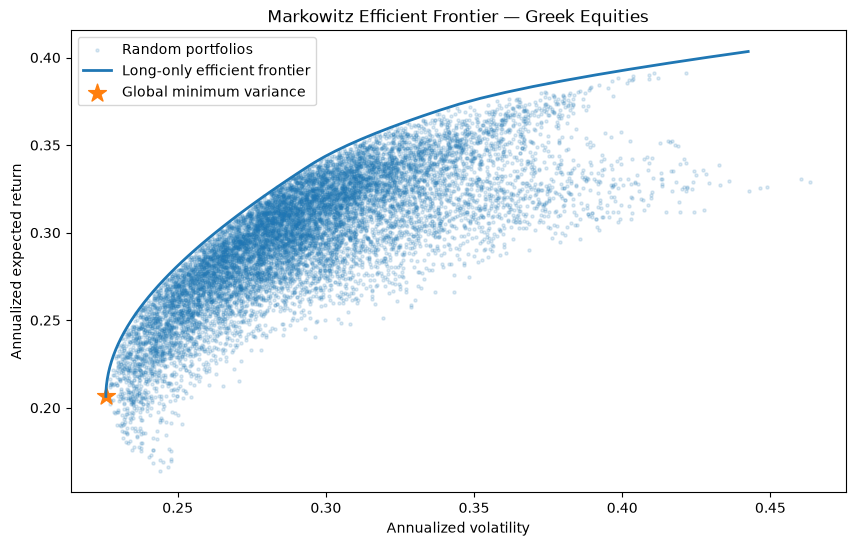

In [24]:
target_min = gmv_return
target_max = float(mu_annual.max())
targets = np.linspace(target_min, target_max, 60)

frontier_returns = []
frontier_vols = []
frontier_weights = []

for target in targets:
    result = min_variance_for_target(
        cov_annual.values,
        mu_annual.values,
        target,
    )

    if result.success:
        w = result.x
        frontier_returns.append(portfolio_return(w, mu_annual.values))
        frontier_vols.append(portfolio_volatility(w, cov_annual.values))
        frontier_weights.append(w)

frontier = pd.DataFrame({
    "return": frontier_returns,
    "volatility": frontier_vols,
})

plt.figure(figsize=(10, 6))
plt.scatter(sim_vols, sim_returns, s=5, alpha=0.15, label="Random portfolios")
plt.plot(
    frontier["volatility"],
    frontier["return"],
    linewidth=2,
    label="Long-only efficient frontier",
)
plt.scatter(
    [gmv_vol],
    [gmv_return],
    marker="*",
    s=180,
    label="Global minimum variance",
)
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized expected return")
plt.title("Markowitz Efficient Frontier — Greek Equities")
plt.legend()
plt.show()

## 8. Risk-free proxy and the tangency portfolio

To introduce the riskless asset without choosing an arbitrary number, the notebook downloads the latest **ECB Deposit Facility Rate** from FRED and uses it as a euro-area short-rate proxy.

The Sharpe ratio is

$$
\boxed{
S_P
=
\frac{E[R_P]-r_f}{\sigma_P}
}.
$$

The tangency portfolio maximizes this quantity:

$$
\boxed{
\max_w
\frac{w^\top\mu-r_f}
{\sqrt{w^\top\Sigma w}}
}.
$$

In [25]:
def load_latest_ecb_deposit_rate():
    url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=ECBDFR"

    df = pd.read_csv(url, na_values=".")

    # FRED may return DATE or observation_date.
    date_col = df.columns[0]
    rate_col = "ECBDFR"

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df[rate_col] = pd.to_numeric(df[rate_col], errors="coerce")

    df = df.dropna(subset=[date_col, rate_col])
    df = df.sort_values(date_col)

    if df.empty:
        raise ValueError("No valid ECB deposit rate observations found.")

    last = df.iloc[-1]

    return last[date_col], float(last[rate_col]) / 100


rf_date, risk_free_rate = load_latest_ecb_deposit_rate()

print("Risk-free proxy date:", rf_date.date())
print(f"ECB Deposit Facility Rate: {risk_free_rate:.2%}")

Risk-free proxy date: 2026-09-18
ECB Deposit Facility Rate: 2.50%


In [26]:
def negative_sharpe(w, mu, cov, rf):
    ret = portfolio_return(w, mu)
    vol = portfolio_volatility(w, cov)

    if vol <= 0:
        return 1e6

    return -((ret - rf) / vol)


constraints_sum = ({
    "type": "eq",
    "fun": lambda w: np.sum(w) - 1,
},)

tangency_result = minimize(
    negative_sharpe,
    X0,
    args=(mu_annual.values, cov_annual.values, risk_free_rate),
    method="SLSQP",
    bounds=BOUNDS,
    constraints=constraints_sum,
)

if not tangency_result.success:
    raise RuntimeError(tangency_result.message)

w_tan = tangency_result.x
tan_return = portfolio_return(w_tan, mu_annual.values)
tan_vol = portfolio_volatility(w_tan, cov_annual.values)
tan_sharpe = (tan_return - risk_free_rate) / tan_vol

tangency_weights = pd.Series(
    w_tan,
    index=asset_names,
    name="Tangency weight",
)

tangency_weights.to_frame()

,Tangency weight
PPC,0.290917
OTE,0.000000
GEK TERNA,0.447123
Motor Oil,0.252883
National Bank,0.009077


## 9. Capital Market Line

The Capital Market Line combines the risk-free asset with the tangency portfolio.

Its equation is

$$
\boxed{
E[R_C]
=
r_f
+
\frac{E[R_M]-r_f}{\sigma_M}
\sigma_C
}
$$

where the slope is the Sharpe ratio of the tangency portfolio.

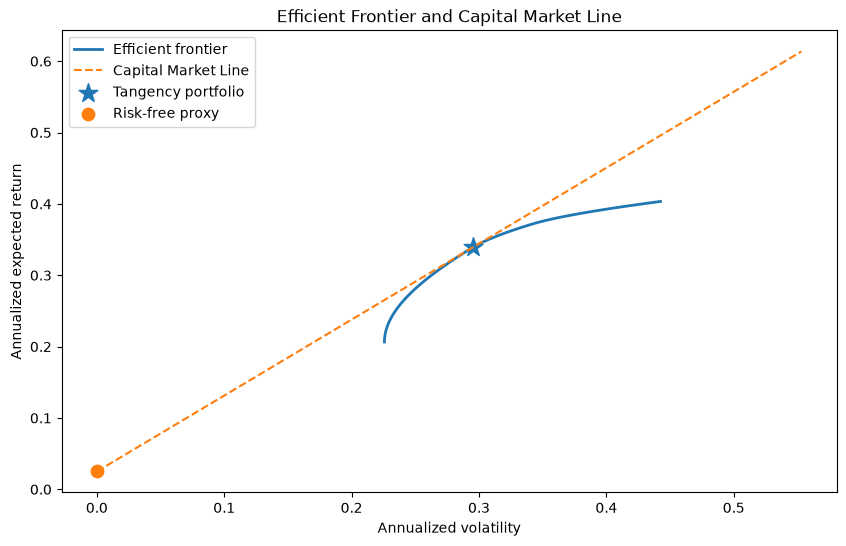

In [27]:
cml_vol = np.linspace(0, max(frontier["volatility"].max(), tan_vol) * 1.25, 100)
cml_return = risk_free_rate + tan_sharpe * cml_vol

plt.figure(figsize=(10, 6))
plt.plot(
    frontier["volatility"],
    frontier["return"],
    linewidth=2,
    label="Efficient frontier",
)
plt.plot(
    cml_vol,
    cml_return,
    linestyle="--",
    label="Capital Market Line",
)
plt.scatter(
    [tan_vol],
    [tan_return],
    marker="*",
    s=200,
    label="Tangency portfolio",
)
plt.scatter(
    [0],
    [risk_free_rate],
    marker="o",
    s=80,
    label="Risk-free proxy",
)
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized expected return")
plt.title("Efficient Frontier and Capital Market Line")
plt.legend()
plt.show()

## 10. CAPM and systematic risk

Using the ATHEX Composite as a market proxy, CAPM relates expected return to systematic risk:

$$
\boxed{
E[R_i]
=
r_f
+
\beta_i
\left(
E[R_M]-r_f
\right)
}
$$

where

$$
\boxed{
\beta_i
=
\frac{Cov(R_i,R_M)}
{Var(R_M)}
}.
$$

We estimate

$$
R_i-r_f
=
\alpha_i
+
\beta_i(R_M-r_f)
+
\varepsilon_i.
$$

- $\beta_i$: systematic market exposure,
- $\alpha_i$: return unexplained by the market model,
- $\varepsilon_i$: idiosyncratic component.

In [28]:
rf_daily = (1 + risk_free_rate) ** (1 / TRADING_DAYS) - 1

market_excess = market_returns - rf_daily

capm_rows = []

for asset in asset_names:
    asset_excess = returns[asset] - rf_daily

    X = np.column_stack([
        np.ones(len(market_excess)),
        market_excess.values,
    ])

    alpha_daily, beta = np.linalg.lstsq(
        X,
        asset_excess.values,
        rcond=None,
    )[0]

    fitted = alpha_daily + beta * market_excess.values
    residuals = asset_excess.values - fitted

    annual_alpha = (1 + alpha_daily) ** TRADING_DAYS - 1
    residual_vol = np.std(residuals, ddof=1) * np.sqrt(TRADING_DAYS)

    capm_expected = (
        risk_free_rate
        + beta * (
            TRADING_DAYS * market_returns.mean()
            - risk_free_rate
        )
    )

    capm_rows.append({
        "asset": asset,
        "alpha_annual": annual_alpha,
        "beta": beta,
        "residual_volatility": residual_vol,
        "historical_annual_return": mu_annual[asset],
        "CAPM_expected_return": capm_expected,
    })

capm = pd.DataFrame(capm_rows).set_index("asset")
capm

,alpha_annual,beta,residual_volatility,historical_annual_return,CAPM_expected_return
asset,,,,,
PPC,0.214115,1.300278,0.329284,0.403453,0.209271
OTE,0.026315,0.647062,0.209169,0.142568,0.116699
GEK TERNA,0.184569,1.015789,0.254658,0.338395,0.168954
Motor Oil,0.121699,0.888706,0.277964,0.265781,0.150944
National Bank,0.067989,1.716511,0.294846,0.334264,0.268258


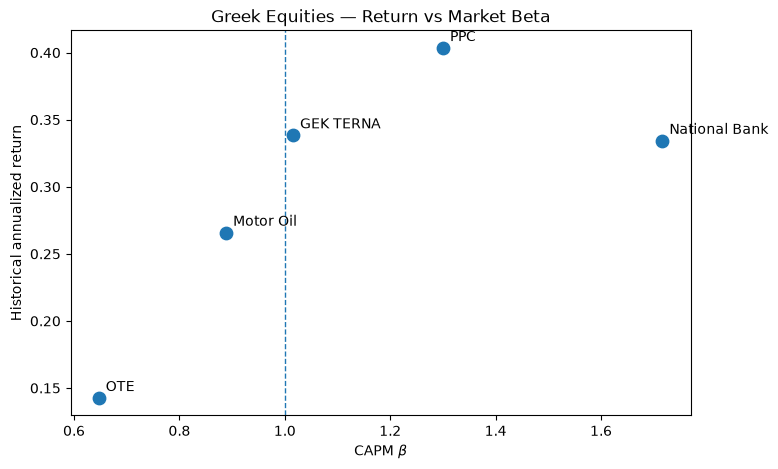

In [29]:
plt.figure(figsize=(8, 5))
plt.scatter(
    capm["beta"],
    capm["historical_annual_return"],
    s=80,
)

for asset in capm.index:
    plt.annotate(
        asset,
        (capm.loc[asset, "beta"], capm.loc[asset, "historical_annual_return"]),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.axvline(1.0, linestyle="--", linewidth=1)
plt.xlabel(r"CAPM $\beta$")
plt.ylabel("Historical annualized return")
plt.title("Greek Equities — Return vs Market Beta")
plt.show()

## 11. Portfolio construction comparison

We compare three portfolios:

1. Equal Weight
2. Global Minimum Variance
3. Maximum Sharpe / Tangency

This makes the optimization output directly interpretable rather than showing the frontier alone.

In [30]:
w_eq = np.repeat(1 / N, N)

portfolio_weights = pd.DataFrame({
    "Equal Weight": w_eq,
    "Global Minimum Variance": w_gmv,
    "Maximum Sharpe": w_tan,
}, index=asset_names)

portfolio_weights

,Equal Weight,Global Minimum Variance,Maximum Sharpe
PPC,0.200000,0.000000,0.290917
OTE,0.200000,0.595889,0.000000
GEK TERNA,0.200000,0.194593,0.447123
Motor Oil,0.200000,0.209518,0.252883
National Bank,0.200000,0.000000,0.009077


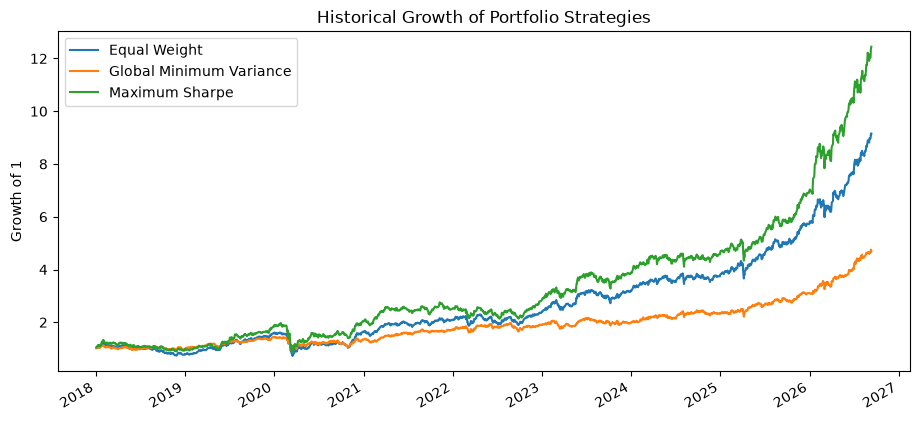

In [31]:
portfolio_daily_returns = pd.DataFrame({
    name: returns.values @ weights
    for name, weights in {
        "Equal Weight": w_eq,
        "Global Minimum Variance": w_gmv,
        "Maximum Sharpe": w_tan,
    }.items()
}, index=returns.index)

wealth = (1 + portfolio_daily_returns).cumprod()

wealth.plot(
    figsize=(11, 5),
    title="Historical Growth of Portfolio Strategies",
)
plt.ylabel("Growth of 1")
plt.xlabel("")
plt.show()

## 12. VaR and CVaR

For confidence level $c=95\%$, Historical Value at Risk is based on the lower-tail return quantile.

Let

$$
q_{0.05}
=
\text{5th percentile of returns}.
$$

We report loss VaR as

$$
\boxed{
VaR_{95}
=
-q_{0.05}
}.
$$

Conditional Value at Risk (Expected Shortfall) is

$$
\boxed{
CVaR_{95}
=
-
E[R_P\mid R_P\le q_{0.05}]
}.
$$

CVaR therefore describes the **average loss after the VaR threshold has already been breached**.

In [32]:
def historical_var_cvar(series, confidence=0.95):
    q = np.quantile(series, 1 - confidence)
    tail = series[series <= q]

    return {
        "Historical VaR": -q,
        "Historical CVaR": -tail.mean(),
    }


def gaussian_var(series, confidence=0.95):
    mu = series.mean()
    sigma = series.std(ddof=1)
    q = mu + norm.ppf(1 - confidence) * sigma
    return -q


risk_rows = []

for name in portfolio_daily_returns.columns:
    r = portfolio_daily_returns[name].dropna()

    hist = historical_var_cvar(r, 0.95)

    risk_rows.append({
        "portfolio": name,
        "Historical VaR 95%": hist["Historical VaR"],
        "Historical CVaR 95%": hist["Historical CVaR"],
        "Gaussian VaR 95%": gaussian_var(r, 0.95),
    })

risk_table = pd.DataFrame(risk_rows).set_index("portfolio")
risk_table

,Historical VaR 95%,Historical CVaR 95%,Gaussian VaR 95%
portfolio,,,
Equal Weight,0.023008,0.039093,0.027240
Global Minimum Variance,0.019211,0.031999,0.022572
Maximum Sharpe,0.022945,0.040640,0.029224


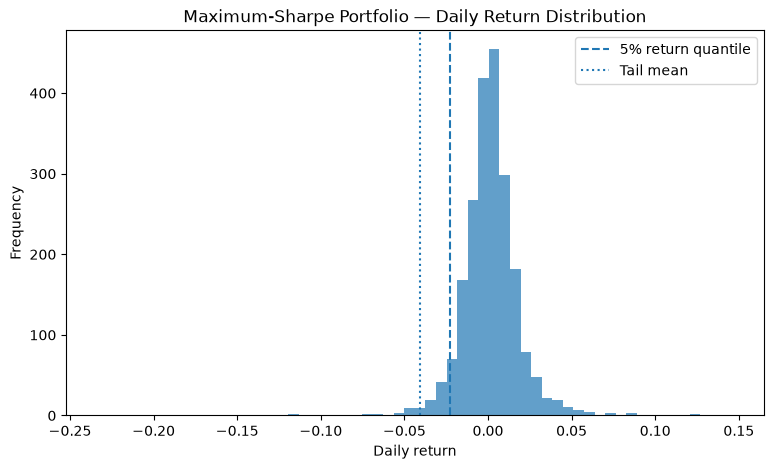

In [33]:
max_sharpe_returns = portfolio_daily_returns["Maximum Sharpe"].dropna()

q05 = np.quantile(max_sharpe_returns, 0.05)
cvar_tail = max_sharpe_returns[max_sharpe_returns <= q05]

plt.figure(figsize=(9, 5))
plt.hist(max_sharpe_returns, bins=60, alpha=0.7)
plt.axvline(q05, linestyle="--", label="5% return quantile")
plt.axvline(cvar_tail.mean(), linestyle=":", label="Tail mean")
plt.title("Maximum-Sharpe Portfolio — Daily Return Distribution")
plt.xlabel("Daily return")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## 13. Portfolio performance indices

The lecture introduces:

### Sharpe ratio

$$
\boxed{
S
=
\frac{E[R_P]-r_f}{\sigma_P}
}
$$

### Treynor ratio

$$
\boxed{
T
=
\frac{E[R_P]-r_f}{\beta_P}
}
$$

### Jensen alpha

From

$$
R_P-r_f
=
\alpha_P
+
\beta_P(R_M-r_f)
+
\varepsilon_P,
$$

the intercept $\alpha_P$ measures abnormal return relative to CAPM.

### Appraisal ratio

$$
\boxed{
AR
=
\frac{\alpha_P}
{\sigma(\varepsilon_P)}
}
$$

which scales Jensen alpha by residual risk.

In [34]:
def max_drawdown(series):
    wealth = (1 + series).cumprod()
    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    return float(drawdown.min())


def portfolio_performance_metrics(series, market, rf_annual):
    ann_return = TRADING_DAYS * series.mean()
    ann_vol = np.sqrt(TRADING_DAYS) * series.std(ddof=1)
    sharpe = (ann_return - rf_annual) / ann_vol

    rf_d = (1 + rf_annual) ** (1 / TRADING_DAYS) - 1
    rp_excess = series - rf_d
    rm_excess = market - rf_d

    X = np.column_stack([np.ones(len(rm_excess)), rm_excess.values])
    alpha_daily, beta = np.linalg.lstsq(
        X,
        rp_excess.values,
        rcond=None,
    )[0]

    fitted = alpha_daily + beta * rm_excess.values
    residuals = rp_excess.values - fitted

    alpha_annual = (1 + alpha_daily) ** TRADING_DAYS - 1
    residual_vol = np.std(residuals, ddof=1) * np.sqrt(TRADING_DAYS)

    treynor = (ann_return - rf_annual) / beta
    appraisal = alpha_annual / residual_vol if residual_vol > 0 else np.nan

    tail = historical_var_cvar(series, 0.95)

    return {
        "Annualized Return": ann_return,
        "Annualized Volatility": ann_vol,
        "Sharpe": sharpe,
        "Beta": beta,
        "Treynor": treynor,
        "Jensen Alpha": alpha_annual,
        "Appraisal Ratio": appraisal,
        "Max Drawdown": max_drawdown(series),
        "VaR 95%": tail["Historical VaR"],
        "CVaR 95%": tail["Historical CVaR"],
    }


performance = pd.DataFrame({
    name: portfolio_performance_metrics(
        portfolio_daily_returns[name],
        market_returns.loc[portfolio_daily_returns.index],
        risk_free_rate,
    )
    for name in portfolio_daily_returns.columns
}).T

performance

,Annualized Return,Annualized Volatility,Sharpe,Beta,Treynor,Jensen Alpha,Appraisal Ratio,Max Drawdown,VaR 95%,CVaR 95%
Equal Weight,0.296892,0.274261,0.991360,1.113669,0.244141,0.120759,1.145081,-0.548460,0.023008,0.039093
Global Minimum Variance,0.206490,0.225752,0.803935,0.769442,0.235872,0.075200,0.526941,-0.410852,0.019211,0.031999
Maximum Sharpe,0.338921,0.295021,1.064064,1.072775,0.292625,0.175645,1.058016,-0.565524,0.022945,0.040640


## 14. Interpretation framework

The project should be read as a **risk-return comparison**, not as a recommendation to buy whichever portfolio has the largest historical return.

Important questions are:

- Which assets provide the most useful diversification?
- How different are the Equal Weight, GMV and Maximum-Sharpe allocations?
- Does the minimum-variance solution concentrate heavily in one stock?
- Which equities have $\beta>1$ or $\beta<1$ relative to the ATHEX Composite?
- Does the portfolio with the highest historical Sharpe also have the lowest tail risk?
- How different are VaR and CVaR across portfolio construction methods?
- How much of portfolio performance is explained by market beta versus residual alpha?

These questions connect the mathematics directly to investment-risk interpretation.

## 15. Multifactor extension

The lecture closes with the general model

$$
R
=
E[R]
+
\beta F
+
\varepsilon,
$$

where $F$ is a vector of systematic risk factors.

This notebook does **not** estimate a multifactor model because the course material does not specify the factor set to use. Adding arbitrary factors would introduce a new modeling assumption rather than simply implementing the lecture.

A future extension could use explicit macro or style factors once the factor definitions are chosen.

## 16. Implementation notes

The supplied classroom notebooks were used as a conceptual and coding reference, but the implementation here is rebuilt rather than copied.

Important portfolio conventions used in this version:

- portfolio optimization uses **simple returns** so $R_P=w^\top R$ is exact,
- annual covariance is computed as $252\Sigma_{\text{daily}}$,
- portfolio volatility is $\sqrt{w^\top\Sigma w}$,
- the Sharpe ratio divides by **volatility**, not variance,
- long-only bounds are explicit,
- VaR and CVaR are reported as positive loss magnitudes,
- the risk-free proxy is downloaded rather than selected arbitrarily.

These choices make the notebook internally consistent and portfolio-ready.

## 17. Limitations

- Historical expected returns are noisy estimates.
- Mean-variance optimization can be sensitive to estimation error.
- The risk-free proxy is the ECB Deposit Facility Rate, not a perfectly investable security for every investor.
- CAPM is a one-factor model and may not fully describe Greek equity returns.
- Historical VaR and CVaR assume the observed sample is informative about future tail risk.
- Transaction costs, taxes, dividends not captured by the chosen data feed, liquidity constraints and position-size limits beyond long-only bounds are outside the current scope.
- Nothing in this notebook constitutes investment advice.